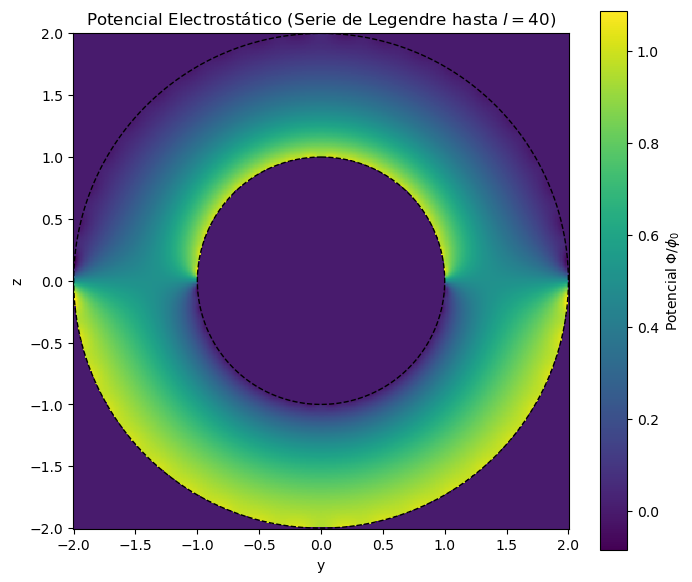

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
a = 1.0        # Radio esfera interior
b = 2.0        # Radio esfera exterior
phi0 = 1.0     # Potencial constante
L_MAX = 40     # Número de términos l (solo impares) para precisión de 3 cifras

def legendre_integral(l):
    """Calcula la integral de 0 a 1 de P_l(x) dx"""
    if l == 0: return 1.0
    if l % 2 == 0: return 0.0 # Integrales para l par > 0 son cero
    # Fórmula recursiva: I_l = (P_{l-1}(0) - P_{l+1}(0)) / (2l + 1)
    from scipy.special import eval_legendre
    return (eval_legendre(l-1, 0) - eval_legendre(l+1, 0)) / (2*l + 1)

# Preparar la malla de puntos
y = np.linspace(-b, b, 400)
z = np.linspace(-b, b, 400)
Y, Z = np.meshgrid(y, z)
R = np.sqrt(Y**2 + Z**2)
Theta = np.arctan2(Y, Z) # Ángulo desde el eje Z (norte)

# Máscara para la región entre las esferas
mask = (R >= a) & (R <= b)
Phi = np.zeros_like(R)

# Cálculo de la serie
from scipy.special import eval_legendre

# Término l = 0 (A0 = phi0/2, B0 = 0)
Phi[mask] += 0.5 * phi0

for l in range(1, L_MAX, 2): # Solo términos impares
    Il = legendre_integral(l)
    factor = (2*l + 1) / 2 * phi0 * Il
    
    # Sistema de ecuaciones:
    # A_l * a^l + B_l / a^(l+1) = factor
    # A_l * b^l + B_l / b^(l+1) = (-1)^l * factor
    
    # Resolvemos para Al y Bl usando l_impar -> (-1)^l = -1
    M = np.array([[a**l, a**(-(l+1))], 
                  [b**l, b**(-(l+1))]])
    v = np.array([factor, -factor])
    Al, Bl = np.linalg.solve(M, v)
    
    # Sumar al potencial en la región válida
    Phi[mask] += (Al * R[mask]**l + Bl * R[mask]**(-(l+1))) * eval_legendre(l, np.cos(Theta[mask]))

# Graficar
plt.figure(figsize=(8, 7))
cp = plt.pcolormesh(Y, Z, Phi, shading='auto')
plt.colorbar(cp, label='Potencial $\Phi/\phi_0$')

# Dibujar las fronteras de las esferas
theta_circ = np.linspace(0, 2*np.pi, 200)
plt.plot(a*np.sin(theta_circ), a*np.cos(theta_circ), 'k--', lw=1)
plt.plot(b*np.sin(theta_circ), b*np.cos(theta_circ), 'k--', lw=1)

plt.title(f'Potencial Electrostático (Serie de Legendre hasta $l={L_MAX}$)')
plt.xlabel('y')
plt.ylabel('z')
plt.gca().set_aspect('equal')
plt.savefig('potencial_esferas_concentricas.png', dpi=300, bbox_inches='tight')
plt.show()

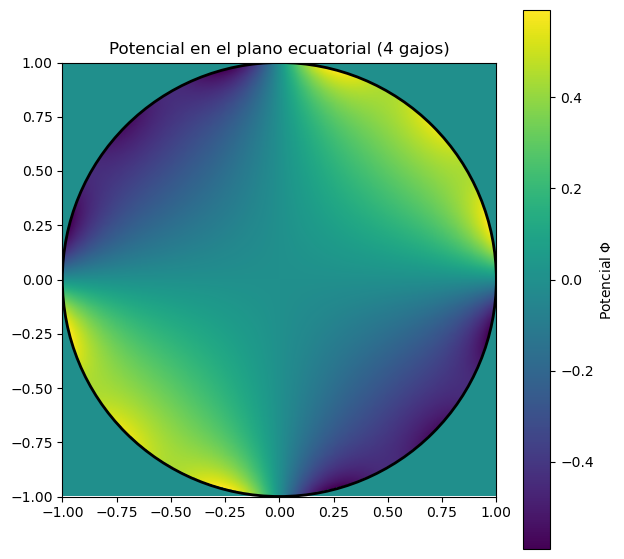

In [10]:
import numpy as np
import matplotlib.pyplot as plt

a = 1.0
phi0 = 1.0
res = 400

# Malla en el plano z=0 (x, y)
x = np.linspace(-a, a, res)
y = np.linspace(-a, a, res)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Phi_coord = np.arctan2(Y, X)

mask = R <= a
Potential = np.zeros_like(R)

# Aproximación de la serie (solo términos dominantes m=2, 6, 10...)
# Para l=m, que son los que más pesan en el ecuador:
for m in [2, 6, 10]:
    # Coeficiente simplificado para la alternancia de 4 gajos
    coeff = (4 * phi0) / (m * np.pi) 
    Potential[mask] += coeff * (R[mask]/a)**m * np.sin(m * Phi_coord[mask])

plt.figure(figsize=(7,7))
im = plt.imshow(Potential, extent=[-a, a, -a, a], origin='lower')
plt.colorbar(im, label='Potencial $\Phi$')
plt.title('Potencial en el plano ecuatorial (4 gajos)')
circle = plt.Circle((0, 0), a, color='black', fill=False, lw=2)
plt.gca().add_patch(circle)
plt.savefig('gajos_esfera.png', dpi=300, bbox_inches='tight')
plt.show()